In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [2]:
np.random.seed(42)

cities = ["Delhi", "Mumbai", "Bangalore", "Hyderabad", "Chennai"]
statuses = ["Completed", "Cancelled"]

data = []

for i in range(500):
    ride = {
        "ride_id": i+1,
        "city": random.choice(cities),
        "hour": np.random.randint(0, 24),
        "fare": np.random.randint(50, 500),
        "ride_status": np.random.choice(statuses, p=[0.8, 0.2])
    }
    data.append(ride)


In [3]:
df=pd.DataFrame(data)
df.head()

,ride_id,city,hour,fare,ride_status
0,1,Mumbai,6,485,Cancelled
1,2,Chennai,10,121,Completed
2,3,Chennai,6,171,Completed
3,4,Delhi,10,137,Completed
4,5,Bangalore,7,201,Completed


In [6]:
peak_hours = df.groupby(["city", "hour"]).size().reset_index(name="rides")

peak_per_city = peak_hours.loc[
    peak_hours.groupby("city")["rides"].idxmax()
]

peak_per_city

,city,hour,rides
11,Bangalore,12,9
33,Chennai,10,8
51,Delhi,5,8
74,Hyderabad,5,6
112,Mumbai,22,9


In [7]:
cancel_rate=df.groupby('city')['ride_status'].apply(
    lambda x:(x=='Cancelled').mean()
).reset_index(name='cancelation_rate')
cancel_rate

,city,cancelation_rate
0,Bangalore,0.173469
1,Chennai,0.184874
2,Delhi,0.220183
3,Hyderabad,0.253165
4,Mumbai,0.263158


In [9]:
hourly_demand=df.groupby('hour').size()
demand_index = hourly_demand / np.max(hourly_demand)
demand_index

hour
0     0.517241
1     0.689655
2     0.896552
3     0.620690
4     0.862069
5     0.827586
6     0.965517
7     0.793103
8     0.517241
9     0.586207
10    0.655172
11    0.482759
12    0.793103
13    0.655172
14    0.551724
15    0.448276
16    1.000000
17    0.620690
18    0.862069
19    0.758621
20    0.827586
21    0.896552
22    0.793103
23    0.620690
dtype: float64

In [10]:
smooth_demand = np.convolve(hourly_demand, np.ones(3)/3, mode='same')

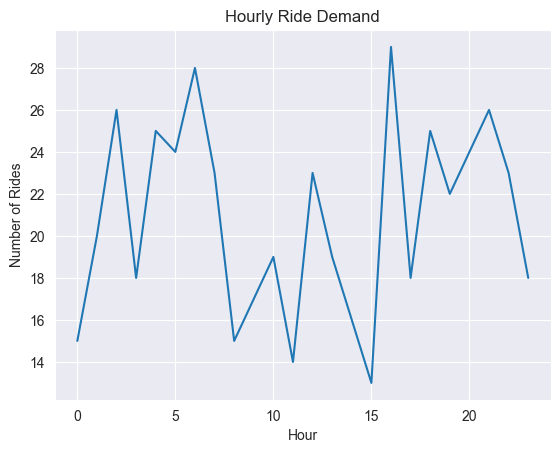

In [11]:
plt.plot(hourly_demand.index, hourly_demand.values)
plt.title("Hourly Ride Demand")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.show()

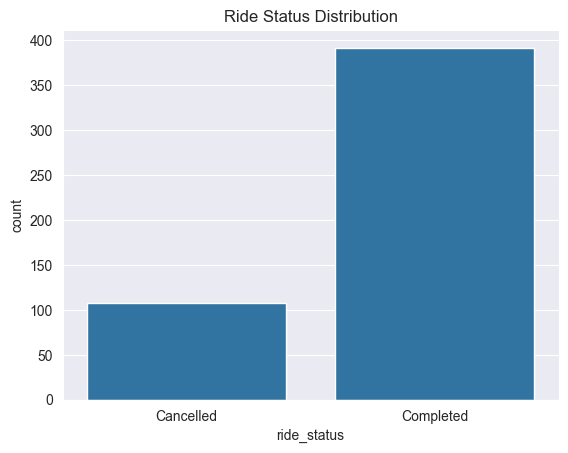

In [12]:
import seaborn as sns

sns.countplot(x="ride_status", data=df)
plt.title("Ride Status Distribution")
plt.show()